# Imports


In [53]:
from __future__ import annotations

import copy
import math
import pickle
from pathlib import Path

import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split

from IPython.display import HTML
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import animation

# Constants


In [54]:
RANDOM_SEED = 42
DATA_DIR = Path("/home/linkezio/Datasets/cifar-10-python/cifar-10-batches-py")
MODELS_DIR = Path("/home/linkezio/Projects/Efficient-Polling-Based-Learning-Rate-Optimization-for-Neural-Networks/models")

# Configs


## Seeds


In [55]:
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## Device


In [56]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

device: cuda


# Data


## Dataset Class


In [57]:
def _load_cifar_batch(path: Path) -> tuple[np.ndarray, np.ndarray]:
    with path.open("rb") as f:
        obj = pickle.load(f, encoding="bytes")
    data = obj[b"data"]  # (N, 3072)
    labels = np.array(obj.get(b"labels") or obj.get(b"fine_labels"), dtype=np.int64)
    return data.reshape(-1, 3, 32, 32), labels


class CIFAR10Dataset(Dataset):
    def __init__(
        self,
        data_dir: Path,
        train: bool,
        mean: torch.Tensor | None = None,
        std: torch.Tensor | None = None,
    ):
        batch_files = (
            [data_dir / f"data_batch_{i}" for i in range(1, 6)]
            if train
            else [data_dir / "test_batch"]
        )

        xs, ys = [], []
        for p in batch_files:
            if not p.exists():
                raise FileNotFoundError(f"File not found: {p}")
            x, y = _load_cifar_batch(p)
            xs.append(x)
            ys.append(y)

        self.images = torch.from_numpy(np.concatenate(xs, axis=0)).float()
        self.labels = torch.from_numpy(np.concatenate(ys, axis=0)).long()

        if (mean is None) ^ (std is None):
            raise ValueError("Pass `mean` and `std` together, or neither.")
        self.mean = mean
        self.std = std

    def __len__(self) -> int:
        return int(self.labels.shape[0])

    def __getitem__(self, idx: int):
        x = self.images[idx]
        if self.mean is not None:
            x = (x - self.mean) / self.std
        return x, self.labels[idx]

## Normalization Statistics


In [58]:
def compute_mean_std(dataset: Dataset, batch_size: int = 512) -> tuple[torch.Tensor, torch.Tensor]:
    channel_sum: torch.Tensor | None = None
    n_pixels = 0
    for images, _ in DataLoader(dataset, batch_size=batch_size, shuffle=False):
        b, c, h, w = images.shape
        if channel_sum is None:
            channel_sum = torch.zeros(c, dtype=torch.float64)
        channel_sum += images.double().sum(dim=(0, 2, 3))
        n_pixels += b * h * w

    mean = (channel_sum / n_pixels).float()

    sum_sq: torch.Tensor | None = None
    for images, _ in DataLoader(dataset, batch_size=batch_size, shuffle=False):
        b, c, h, w = images.shape
        if sum_sq is None:
            sum_sq = torch.zeros(c, dtype=torch.float64)
        diff = images.double() - mean.view(1, c, 1, 1).double()
        sum_sq += (diff ** 2).sum(dim=(0, 2, 3))

    std = torch.sqrt((sum_sq / n_pixels).float())
    return mean, torch.clamp(std, min=1e-8)

In [59]:
train_for_stats = CIFAR10Dataset(DATA_DIR, train=True)

cifar_mean, cifar_std = compute_mean_std(train_for_stats)

cifar_mean = cifar_mean.view(3, 1, 1)
cifar_std = cifar_std.view(3, 1, 1)

print("mean (R,G,B):", cifar_mean.squeeze().tolist())
print("std  (R,G,B):", cifar_std.squeeze().tolist())

/tmp/ipykernel_1313414/2508864993.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  obj = pickle.load(f, encoding="bytes")


mean (R,G,B): [125.30691528320312, 122.95039367675781, 113.86538696289062]
std  (R,G,B): [62.993221282958984, 62.088706970214844, 66.70490264892578]


## Train, Validation, Test Split


In [60]:
class DataLoaderHyperparameters:
    batch_size: int = 64
    val_fraction: float = 0.1
    num_workers: int = 0 # Jupyter: use 0 (workers cannot resolve classes defined in __main__ during pickling).

data_loader_hyperparameters = DataLoaderHyperparameters()

In [61]:
full_train = CIFAR10Dataset(DATA_DIR, train=True, mean=cifar_mean, std=cifar_std)
test_ds = CIFAR10Dataset(DATA_DIR, train=False, mean=cifar_mean, std=cifar_std)

val_size = max(1, int(len(full_train) * data_loader_hyperparameters.val_fraction))
train_size = len(full_train) - val_size

train_ds, val_ds = random_split(
    full_train,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

train_loader = DataLoader(
    train_ds,
    batch_size=data_loader_hyperparameters.batch_size,
    shuffle=True,
    num_workers=data_loader_hyperparameters.num_workers,
    pin_memory=(DEVICE == "cuda"),
)
val_loader = DataLoader(
    val_ds,
    batch_size=data_loader_hyperparameters.batch_size,
    shuffle=False,
    num_workers=data_loader_hyperparameters.num_workers,
    pin_memory=(DEVICE == "cuda"),
)
test_loader = DataLoader(
    test_ds,
    batch_size=data_loader_hyperparameters.batch_size,
    shuffle=False,
    num_workers=data_loader_hyperparameters.num_workers,
    pin_memory=(DEVICE == "cuda"),
)

len(train_ds), len(val_ds), len(test_ds)


/tmp/ipykernel_1313414/2508864993.py:3: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  obj = pickle.load(f, encoding="bytes")


(45000, 5000, 10000)

# Model


## Hyperparameters


In [62]:
class ModelHyperparameters:
    epochs: int = 150
    lr: float = 1e-3
    weight_decay: float = 5e-4


model_hyperparameters = ModelHyperparameters()

## Model Class


In [63]:
class SimpleCIFAR10CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(256, 10),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

# Train


## Metric Functions


In [64]:
def accuracy(logits: torch.Tensor, y: torch.Tensor) -> float:
    return (logits.argmax(dim=1) == y).float().mean().item()

In [65]:
loss_fn = nn.CrossEntropyLoss()

## Epoch Functions


In [66]:
@torch.inference_mode()
def eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    loss_fn: nn.Module,
) -> tuple[float, float]:
    model.eval()
    losses, accs = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        losses.append(loss_fn(logits, y).item())
        accs.append(accuracy(logits, y))
    return float(np.mean(losses)), float(np.mean(accs))


def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
) -> tuple[float, float]:
    model.train()
    losses, accs = [], []
    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optim.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()
        optim.step()
        losses.append(loss.item())
        accs.append(accuracy(logits.detach(), y))
    return float(np.mean(losses)), float(np.mean(accs))


def train_epoch_polling(
    model: nn.Module,
    loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    candidate_lrs: tuple[float, ...],
) -> tuple[float, float, float]:
    model.train()
    losses, accs, chosen_lrs = [], [], []

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optim.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()

        base_model_state = copy.deepcopy(model.state_dict())
        base_optim_state = copy.deepcopy(optim.state_dict())

        best_acc = -1.0
        best_lr = candidate_lrs[0]
        best_snapshot: tuple | None = None

        for lr in candidate_lrs:
            model.load_state_dict(base_model_state)
            optim.load_state_dict(base_optim_state)
            for pg in optim.param_groups:
                pg["lr"] = lr
            optim.step()

            with torch.no_grad():
                acc_try = accuracy(model(x), y)

            if acc_try > best_acc:
                best_acc = acc_try
                best_lr = lr
                best_snapshot = (
                    copy.deepcopy(model.state_dict()),
                    copy.deepcopy(optim.state_dict()),
                )

        assert best_snapshot is not None
        model.load_state_dict(best_snapshot[0])
        optim.load_state_dict(best_snapshot[1])

        with torch.no_grad():
            logits_final = model(x)
            losses.append(loss_fn(logits_final, y).item())
            accs.append(accuracy(logits_final, y))
        chosen_lrs.append(best_lr)

    return float(np.mean(losses)), float(np.mean(accs)), float(np.mean(chosen_lrs))



## Training Runs


### Baseline


In [67]:
def fit_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    model_path: Path,
) -> tuple[dict[str, list[float]], float, Path]:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    history: dict[str, list[float]] = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": [],
    }
    best_val_acc = -math.inf

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optim, loss_fn)
        va_loss, va_acc = eval_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(float(optim.param_groups[0]["lr"]))

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), model_path)

        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )

    print("best val acc:", best_val_acc, "saved:", str(model_path))
    return history, best_val_acc, model_path

In [68]:
model_baseline = SimpleCIFAR10CNN().to(DEVICE)
optim_baseline = torch.optim.SGD(
    model_baseline.parameters(),
    lr=model_hyperparameters.lr,
)

In [69]:
history_baseline, best_val_acc_baseline, model_path_baseline = fit_model(
    model=model_baseline,
    train_loader=train_loader,
    val_loader=val_loader,
    optim=optim_baseline,
    loss_fn=loss_fn,
    epochs=model_hyperparameters.epochs,
    model_path=MODELS_DIR / "cifar10_best.pt",
)

epoch 01/150 | train loss 2.3027 acc 0.0998 | val loss 2.3024 acc 0.0997


KeyboardInterrupt: 

### Polling Method


In [ ]:
class PollingHyperparameters:
    candidate_lrs: tuple[float, ...] = (
        float(model_hyperparameters.lr * 10**-2),
        float(model_hyperparameters.lr * 10**-1),
        float(model_hyperparameters.lr),
        float(model_hyperparameters.lr * 10**1),
        float(model_hyperparameters.lr * 10**2),
    )


polling_hyperparameters = PollingHyperparameters()

In [ ]:
def fit_model_polling(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    candidate_lrs: tuple[float, ...],
    model_path: Path,
) -> tuple[dict[str, list[float]], float, Path]:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)

    history: dict[str, list[float]] = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }

    best_val_acc = -math.inf

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, mean_lr = train_epoch_polling(
            model, train_loader, optim, loss_fn, candidate_lrs
        )
        va_loss, va_acc = eval_epoch(model, val_loader, loss_fn)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(mean_lr)

        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), model_path)

        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"mean train-chosen lr {mean_lr:.6f} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )

    print("best val acc:", best_val_acc, "saved:", str(model_path))
    return history, best_val_acc, model_path



In [ ]:
model_polling = SimpleCIFAR10CNN().to(DEVICE)
optim_polling = torch.optim.SGD(
    model_polling.parameters(),
    lr=model_hyperparameters.lr,
)

In [ ]:
history_polling, best_val_acc_polling, model_path_polling = fit_model_polling(
    model=model_polling,
    train_loader=train_loader,
    val_loader=val_loader,
    optim=optim_polling,
    loss_fn=loss_fn,
    epochs=model_hyperparameters.epochs,
    candidate_lrs=polling_hyperparameters.candidate_lrs,
    model_path=MODELS_DIR / "cifar10_best_polling_base.pt",
)


epoch 01/150 | mean train-chosen lr 0.048457 | train loss 2.1612 acc 0.2045 | val loss 2.4807 acc 0.1701
epoch 02/150 | mean train-chosen lr 0.064553 | train loss 1.8320 acc 0.3355 | val loss 2.1075 acc 0.2613
epoch 03/150 | mean train-chosen lr 0.071844 | train loss 1.6217 acc 0.4212 | val loss 1.5864 acc 0.4177
epoch 04/150 | mean train-chosen lr 0.069906 | train loss 1.4826 acc 0.4811 | val loss 1.6995 acc 0.3445
epoch 05/150 | mean train-chosen lr 0.083106 | train loss 1.3068 acc 0.5438 | val loss 1.6118 acc 0.3797
epoch 06/150 | mean train-chosen lr 0.082016 | train loss 1.1670 acc 0.5983 | val loss 1.2514 acc 0.5429
epoch 07/150 | mean train-chosen lr 0.084466 | train loss 1.0392 acc 0.6450 | val loss 1.1190 acc 0.6068
epoch 08/150 | mean train-chosen lr 0.086455 | train loss 0.9370 acc 0.6831 | val loss 2.4291 acc 0.3794
epoch 09/150 | mean train-chosen lr 0.089299 | train loss 0.8399 acc 0.7190 | val loss 1.7229 acc 0.4773
epoch 10/150 | mean train-chosen lr 0.090203 | train lo

### Adaptive Polling

In [ ]:
class AdaptivePollingHyperparameters:
    candidate_factors: tuple[float, ...] = (0.1, 0.3, 1.0, 3.0, 10.0)

adaptive_polling_hyperparameters = AdaptivePollingHyperparameters()


def train_epoch_adaptive_polling(
    model: nn.Module,
    loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    candidate_factors: tuple[float, ...],
) -> tuple[float, float, float]:
    model.train()
    losses, accs, chosen_lrs = [], [], []

    current_lr = optim.param_groups[0]["lr"]

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optim.zero_grad(set_to_none=True)
        logits = model(x)
        loss = loss_fn(logits, y)
        loss.backward()

        # Try current LR first; only switch if another is strictly better
        ordered_factors = [1.0] + [f for f in candidate_factors if f != 1.0]
        candidate_lrs = [current_lr * f for f in ordered_factors]

        base_model_state = copy.deepcopy(model.state_dict())
        base_optim_state = copy.deepcopy(optim.state_dict())

        best_acc = -1.0
        best_lr = candidate_lrs[0]
        best_snapshot: tuple | None = None

        for lr in candidate_lrs:
            model.load_state_dict(base_model_state)
            optim.load_state_dict(base_optim_state)
            for pg in optim.param_groups:
                pg["lr"] = lr
            optim.step()

            with torch.no_grad():
                acc_try = accuracy(model(x), y)

            if acc_try > best_acc:
                best_acc = acc_try
                best_lr = lr
                best_snapshot = (
                    copy.deepcopy(model.state_dict()),
                    copy.deepcopy(optim.state_dict()),
                )

        assert best_snapshot is not None
        model.load_state_dict(best_snapshot[0])
        optim.load_state_dict(best_snapshot[1])

        current_lr = best_lr
        for pg in optim.param_groups:
            pg["lr"] = current_lr

        with torch.no_grad():
            logits_final = model(x)
            losses.append(loss_fn(logits_final, y).item())
            accs.append(accuracy(logits_final, y))
        chosen_lrs.append(best_lr)

    return float(np.mean(losses)), float(np.mean(accs)), float(np.mean(chosen_lrs))


def fit_model_adaptive_polling(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    optim: torch.optim.Optimizer,
    loss_fn: nn.Module,
    epochs: int,
    candidate_factors: tuple[float, ...],
    model_path: Path,
) -> tuple[dict[str, list[float]], float, Path]:
    MODELS_DIR.mkdir(parents=True, exist_ok=True)
    history: dict[str, list[float]] = {
        "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": [],
    }
    best_val_acc = -math.inf
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc, mean_lr = train_epoch_adaptive_polling(
            model, train_loader, optim, loss_fn, candidate_factors
        )
        va_loss, va_acc = eval_epoch(model, val_loader, loss_fn)
        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)
        history["lr"].append(mean_lr)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            torch.save(model.state_dict(), model_path)
        print(
            f"epoch {epoch:02d}/{epochs} | "
            f"mean lr {mean_lr:.6f} | "
            f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
            f"val loss {va_loss:.4f} acc {va_acc:.4f}"
        )
    print("best val acc:", best_val_acc, "saved:", str(model_path))
    return history, best_val_acc, model_path

In [71]:
model_adaptive_polling = SimpleCIFAR10CNN().to(DEVICE)
optim_adaptive_polling = torch.optim.SGD(
    model_adaptive_polling.parameters(),
    lr=model_hyperparameters.lr,
)

In [72]:
history_adaptive_polling, best_val_acc_adaptive_polling, model_path_adaptive_polling = fit_model_adaptive_polling(
    model=model_adaptive_polling,
    train_loader=train_loader,
    val_loader=val_loader,
    optim=optim_adaptive_polling,
    loss_fn=loss_fn,
    epochs=model_hyperparameters.epochs,
    candidate_factors=adaptive_polling_hyperparameters.candidate_factors,
    model_path=MODELS_DIR / "cifar10_best_adaptive_polling.pt",
)

epoch 01/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0997 | val loss 2.3027 acc 0.1017
epoch 02/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0997 | val loss 2.3027 acc 0.1017
epoch 03/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0999 | val loss 2.3027 acc 0.1017
epoch 04/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0996 | val loss 2.3027 acc 0.1017
epoch 05/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0999 | val loss 2.3027 acc 0.1017
epoch 06/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0999 | val loss 2.3027 acc 0.1017
epoch 07/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0997 | val loss 2.3027 acc 0.1017
epoch 08/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0999 | val loss 2.3027 acc 0.1017
epoch 09/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0997 | val loss 2.3027 acc 0.1017
epoch 10/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0996 | val loss 2.3027 acc 0.1017
epoch 11/150 | mean lr 0.000000 | train loss 2.3031 acc 0.0996 | val loss 2.3027

KeyboardInterrupt: 

## Training Animation


### LR Overlay Animation (all methods, symlog scale)

In [ ]:
def animate_lr_overlay(
    histories: list[dict],
    titles: list[str] | None = None,
    interval_ms: int = 80,
    linthresh: float = 1e-4,
    ylim_percentile: tuple[float, float] = (2, 98),
) -> HTML:
    n_runs = len(histories)
    if titles is None:
        titles = [f"Run {j+1}" for j in range(n_runs)]

    n_epochs = len(histories[0]["lr"])
    epochs = np.arange(1, n_epochs + 1)
    lrs = [np.asarray(h.get("lr", [float("nan")] * n_epochs), dtype=float) for h in histories]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.set_title("Mean Learning Rate per Epoch — All Methods (symlog scale)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_yscale("symlog", linthresh=linthresh)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlim(0.5, n_epochs + 0.5)

    colors = [f"C{i}" for i in range(n_runs)]
    lines, dots = [], []
    for j in range(n_runs):
        (ln,) = ax.plot([], [], label=titles[j], color=colors[j], linewidth=1.5)
        dot = ax.scatter([], [], color=colors[j], s=40, zorder=5)
        lines.append(ln)
        dots.append(dot)

    vline = ax.axvline(1, color="gray", ls="--", alpha=0.5)
    ax.legend(loc="upper left")

    all_positive = np.concatenate([lr[np.isfinite(lr) & (lr > 0)] for lr in lrs])
    if len(all_positive):
        hi = float(np.percentile(all_positive, ylim_percentile[1]))
        ax.set_ylim(0, hi * 1.15)

    def init():
        return []

    def update(k: int):
        sl = slice(0, k + 1)
        ex = epochs[sl]
        for j in range(n_runs):
            lines[j].set_data(ex, lrs[j][sl])
            dots[j].set_offsets(np.c_[ex[-1:], lrs[j][sl][-1:]])
        vline.set_xdata([float(epochs[k]), float(epochs[k])])
        return []

    anim = animation.FuncAnimation(
        fig, update, frames=n_epochs, init_func=init, interval=interval_ms, blit=False,
    )
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
animate_lr_overlay(
    [history_baseline, history_polling, history_adaptive_polling],
    titles=["Baseline", "Polling", "Adaptive Polling"],
)

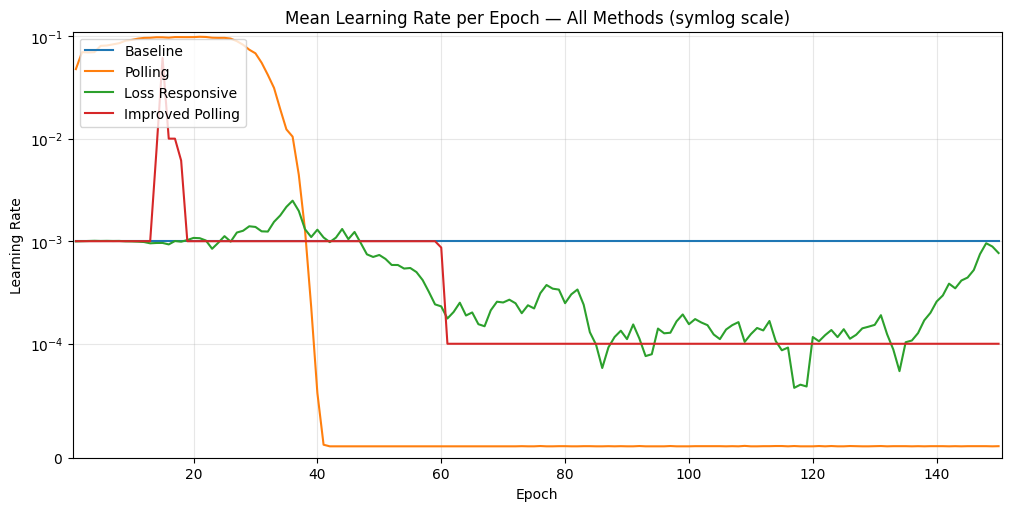

Saved: ../images/training_comparison_LRs.png


In [ ]:
def save_lr_comparison(
    histories: list[dict],
    titles: list[str] | None = None,
    linthresh: float = 1e-4,
    save_path: str = "../images/training_comparison_LRs.png",
) -> None:
    n_runs = len(histories)
    if titles is None:
        titles = [f"Run {j+1}" for j in range(n_runs)]

    n_epochs = len(histories[0]["lr"])
    epochs = np.arange(1, n_epochs + 1)
    lrs = [np.asarray(h.get("lr", [float("nan")] * n_epochs), dtype=float) for h in histories]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.set_title("Mean Learning Rate per Epoch — All Methods (symlog scale)")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Learning Rate")
    ax.set_yscale("symlog", linthresh=linthresh)
    ax.grid(True, which="both", alpha=0.3)
    ax.set_xlim(0.5, n_epochs + 0.5)

    colors = [f"C{i}" for i in range(n_runs)]
    for j in range(n_runs):
        ax.plot(epochs, lrs[j], label=titles[j], color=colors[j], linewidth=1.5)

    ax.legend(loc="upper left")
    all_positive = np.concatenate([lr[np.isfinite(lr) & (lr > 0)] for lr in lrs])
    if len(all_positive):
        hi = float(np.percentile(all_positive, 98))
        ax.set_ylim(0, hi * 1.15)

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


save_lr_comparison(
    [history_baseline, history_polling, history_adaptive_polling],
    titles=["Baseline", "Polling", "Adaptive Polling"],
)

### Loss Overlay Animation (all methods, symlog scale)

In [ ]:
def animate_loss_overlay(
    histories: list[dict],
    titles: list[str] | None = None,
    interval_ms: int = 80,
    ylim_percentile: tuple[float, float] = (0, 98),
) -> HTML:
    n_runs = len(histories)
    if titles is None:
        titles = [f"Run {j+1}" for j in range(n_runs)]

    n_epochs = len(histories[0]["train_loss"])
    epochs = np.arange(1, n_epochs + 1)
    train_losses = [np.asarray(h["train_loss"], dtype=float) for h in histories]
    val_losses   = [np.asarray(h["val_loss"],   dtype=float) for h in histories]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.set_title("Loss per Epoch — All Methods")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, n_epochs + 0.5)

    colors = [f"C{i}" for i in range(n_runs)]
    train_lines, val_lines = [], []
    train_dots, val_dots   = [], []
    for j in range(n_runs):
        (tl,) = ax.plot([], [], color=colors[j], linewidth=1.5,
                        linestyle="--", alpha=0.6, label=f"{titles[j]} train")
        (vl,) = ax.plot([], [], color=colors[j], linewidth=1.5,
                        label=f"{titles[j]} val")
        train_lines.append(tl)
        val_lines.append(vl)
        train_dots.append(ax.scatter([], [], color=colors[j], s=30, alpha=0.6, zorder=5))
        val_dots.append(ax.scatter([], [], color=colors[j], s=40, zorder=5))

    vline = ax.axvline(1, color="gray", ls="--", alpha=0.5)
    ax.legend(loc="upper right", fontsize=7, ncol=2)

    all_vals = np.concatenate(train_losses + val_losses)
    all_finite = all_vals[np.isfinite(all_vals)]
    if len(all_finite):
        lo = float(np.percentile(all_finite, ylim_percentile[0]))
        hi = float(np.percentile(all_finite, ylim_percentile[1]))
        pad = (hi - lo) * 0.08
        ax.set_ylim(max(0, lo - pad), hi + pad)

    def init():
        return []

    def update(k: int):
        sl = slice(0, k + 1)
        ex = epochs[sl]
        for j in range(n_runs):
            train_lines[j].set_data(ex, train_losses[j][sl])
            val_lines[j].set_data(ex, val_losses[j][sl])
            train_dots[j].set_offsets(np.c_[ex[-1:], train_losses[j][sl][-1:]])
            val_dots[j].set_offsets(np.c_[ex[-1:], val_losses[j][sl][-1:]])
        vline.set_xdata([float(epochs[k]), float(epochs[k])])
        return []

    anim = animation.FuncAnimation(
        fig, update, frames=n_epochs, init_func=init, interval=interval_ms, blit=False,
    )
    plt.close(fig)
    return HTML(anim.to_jshtml())

In [ ]:
animate_loss_overlay(
    [history_baseline, history_polling, history_adaptive_polling],
    titles=["Baseline", "Polling", "Adaptive Polling"],
)

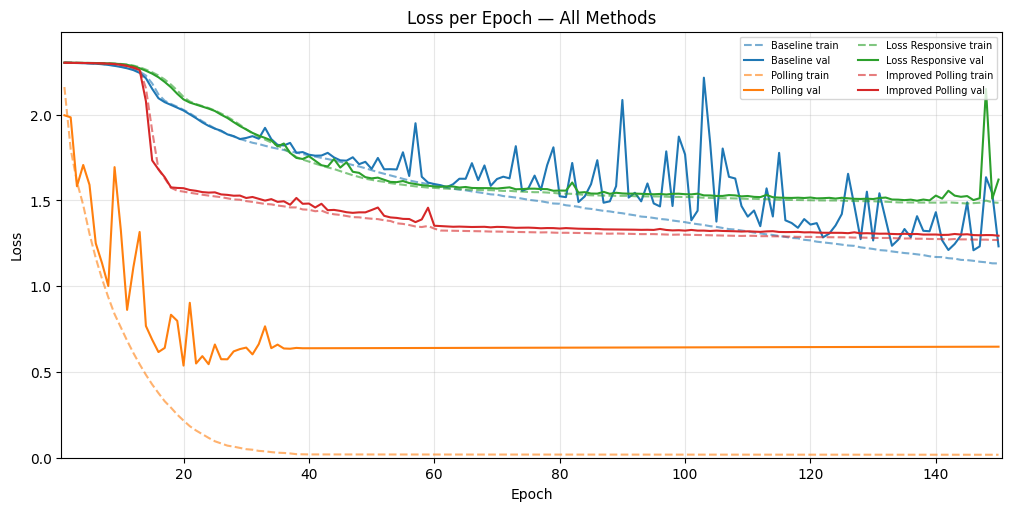

Saved: ../images/training_comparison_losses.png


In [ ]:
def save_loss_comparison(
    histories: list[dict],
    titles: list[str] | None = None,
    ylim_percentile: tuple[float, float] = (0, 98),
    save_path: str = "../images/training_comparison_losses.png",
) -> None:
    n_runs = len(histories)
    if titles is None:
        titles = [f"Run {j+1}" for j in range(n_runs)]

    n_epochs = len(histories[0]["train_loss"])
    epochs = np.arange(1, n_epochs + 1)
    train_losses = [np.asarray(h["train_loss"], dtype=float) for h in histories]
    val_losses   = [np.asarray(h["val_loss"],   dtype=float) for h in histories]

    fig, ax = plt.subplots(figsize=(10, 5), constrained_layout=True)
    ax.set_title("Loss per Epoch — All Methods")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0.5, n_epochs + 0.5)

    colors = [f"C{i}" for i in range(n_runs)]
    for j in range(n_runs):
        ax.plot(epochs, train_losses[j], color=colors[j], linewidth=1.5,
                linestyle="--", alpha=0.6, label=f"{titles[j]} train")
        ax.plot(epochs, val_losses[j], color=colors[j], linewidth=1.5,
                label=f"{titles[j]} val")

    ax.legend(loc="upper right", fontsize=7, ncol=2)
    all_vals = np.concatenate(train_losses + val_losses)
    all_finite = all_vals[np.isfinite(all_vals)]
    if len(all_finite):
        lo = float(np.percentile(all_finite, ylim_percentile[0]))
        hi = float(np.percentile(all_finite, ylim_percentile[1]))
        pad = (hi - lo) * 0.08
        ax.set_ylim(max(0, lo - pad), hi + pad)

    fig.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {save_path}")


save_loss_comparison(
    [history_baseline, history_polling, history_adaptive_polling],
    titles=["Baseline", "Polling", "Adaptive Polling"],
)

# Test


In [ ]:
model_baseline.load_state_dict(torch.load(MODELS_DIR / "cifar10_best.pt", map_location=DEVICE))
test_loss, test_acc = eval_epoch(model_baseline, test_loader, loss_fn)
print(f"Baseline | test loss {test_loss:.4f} | test acc {test_acc:.4f}")

Baseline | test loss 1.2153 | test acc 0.5675


In [ ]:
model_polling.load_state_dict(torch.load(MODELS_DIR / "cifar10_best_polling_base.pt", map_location=DEVICE))
test_loss, test_acc = eval_epoch(model_polling, test_loader, loss_fn)
print(f"Polling         | test loss {test_loss:.4f} | test acc {test_acc:.4f}")

Polling         | test loss 0.6895 | test acc 0.8359


In [ ]:
model_adaptive_polling.load_state_dict(torch.load(MODELS_DIR / "cifar10_best_adaptive_polling.pt", map_location=DEVICE))
test_loss, test_acc = eval_epoch(model_adaptive_polling, test_loader, loss_fn)
print(f"Adaptive Polling | test loss {test_loss:.4f} | test acc {test_acc:.4f}")